# HistColorbar: A Beginner-Friendly Tutorial

This tutorial helps you quickly and comprehensively learn how to use [](faninsar.plotting.HistColorbar).
It embeds a histogram next to a colorbar so you can see how your data are distributed across the colormap range.

You will learn:
- What HistColorbar is and when to use it
- `ax` vs `cax` (steal space vs dedicated axes)
- `location` and `orientation` and how they relate
- Layout controls: `fraction` and `hist_fraction`
- Handling out-of-range values with `extend`
- Log-scale histogram counts and `min_count`
- Styling: `outline`, `divider_style`, labels, and ticks
- Using with `imshow`, `contourf`, and `pcolormesh`
- Complex layouts (e.g., `subplot_mosaic`)
- Best practices, troubleshooting, and an API cheat sheet

:::{tip}
Importing `faninsar.plotting` registers `Figure.hist_colorbar` on Matplotlib's Figure,
so you can call `fig.hist_colorbar(...)` directly.
:::

Below, each section provides a short explanation followed by a runnable example.

## What and Why
- A regular colorbar shows the mapping from data values to colors.
- HistColorbar augments this with a histogram of your actual data,
  helping you judge dynamic range, saturation, and whether your `norm` is appropriate.
- This is especially useful for heavy-tailed or highly skewed data, or when choosing thresholds.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Import to register Figure.hist_colorbar
from faninsar.plotting import HistColorbar

plt.rcParams['image.cmap'] = 'viridis'
np.random.seed(0)

def generate_data(n=256, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(-3, 3, n)
    y = np.linspace(-3, 3, n)
    X, Y = np.meshgrid(x, y)
    Z = (np.sin(X**2 + Y**2) / (1 + 0.3*(X**2 + Y**2))
         + 0.15*rng.standard_normal((n, n)))
    return X, Y, Z

## 1) Quick Start (Right, Vertical)
This is the simplest pattern. Provide your mappable (e.g., from `imshow`) and the same data.
HistColorbar will auto-derive `cmap` and `norm` from the mappable, and place on the right by default. The data will be used to create the histogram.

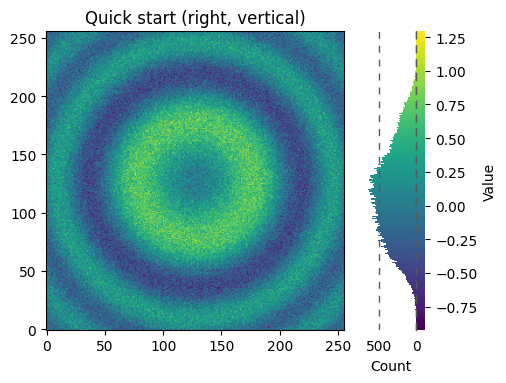

In [13]:
X, Y, Z = generate_data(256, seed=1)
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
im = ax.imshow(Z, origin='lower')
ax.set_title('Quick start (right, vertical)')
hcb = HistColorbar(data=Z, mappable=im, ax=ax, label='Value', hist_label='Count')

Since `hist_colorbar` has been registered to matplotlib's Figure class, we can create a HistColorbar instance directly from the figure object. All parameters are passed directly to the HistColorbar class constructor.

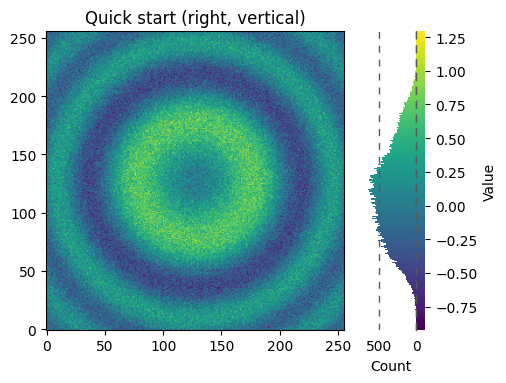

In [14]:
X, Y, Z = generate_data(256, seed=1)
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
im = ax.imshow(Z, origin='lower')
ax.set_title('Quick start (right, vertical)')
hcb = fig.hist_colorbar(data=Z, mappable=im, ax=ax, label='Value', hist_label='Count')

## 2) `ax` vs `cax` (Steal Space vs Dedicated Axes)
- Use `ax` to let HistColorbar steal space from the plot axes (simpler, fewer moving parts).
- Use `cax` when you need a fixed, dedicated area for the colorbar, or when you want to avoid shrinking the plot.

:::{tip}
Rule of thumb: start with `ax`. Switch to `cax` only when the layout needs precise control.
:::

The simplest case is just attaching a colorbar to each Axes. Note in this example that the colorbars steal some space from the parent Axes.

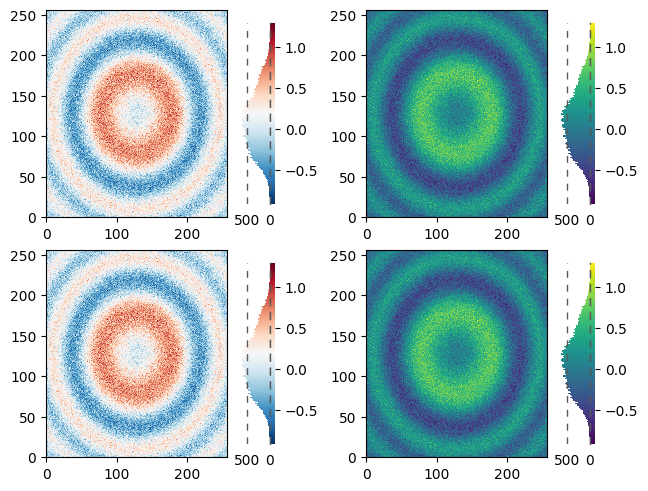

In [84]:
X, Y, Z = generate_data(256, seed=1)

fig, axs = plt.subplots(2, 2, layout='constrained')
cmaps = ['RdBu_r', 'viridis']
for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        pcm = ax.pcolormesh(Z, cmap=cmaps[col])
        fig.hist_colorbar(Z, pcm, ax=ax)
plt.show()

The first column has the same type of data in both rows, so it may be desirable to have just one colorbar. We do this by passing Figure.hist_colorbar a list of Axes with the ax kwarg.

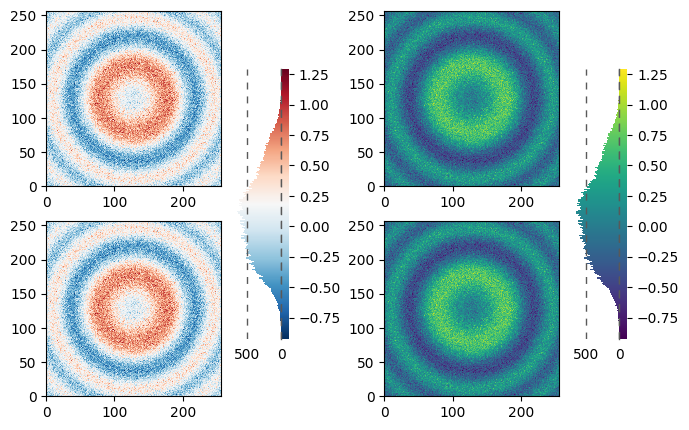

In [95]:
fig, axs = plt.subplots(2, 2, figsize=(8, 5))
cmaps = ['RdBu_r', 'viridis']
for col in range(2):
    for row in range(2):
        ax = axs[row, col]
        ax.set_aspect('equal')
        pcm = ax.pcolormesh(Z, cmap=cmaps[col])
    fig.hist_colorbar(Z, pcm, ax=axs[:, col], shrink=0.7)

The stolen space can lead to Axes in the same subplot layout being different sizes, which is often undesired if the the x/y-axis on each plot is meant to be comparable as in the following:

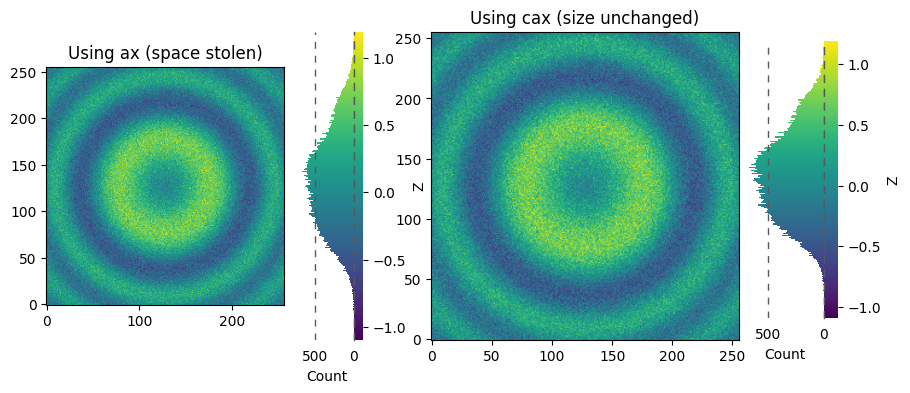

In [17]:
X, Y, Z = generate_data(256, seed=2)
fig = plt.figure(figsize=(9, 4))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

# Left: using ax (steals space)
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(Z, origin='lower')
ax1.set_title('Using ax (space stolen)')
fig.hist_colorbar(data=Z, mappable=im1, ax=ax1, location='right', label='Z', hist_label='Count')

# Right: using cax (no effect on subplot size)
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(Z, origin='lower')
ax2.set_title('Using cax (size unchanged)')
cax2 = inset_axes(ax2, width='30%', height='90%', loc='lower left',
                  bbox_to_anchor=(1.02, 0.07, 1, 1),
                  bbox_transform=ax2.transAxes, borderpad=0)
fig.hist_colorbar(data=Z, mappable=im2, cax=cax2, location='right', label='Z', hist_label='Count')
plt.show()

This is usually undesired, and can be worked around in various ways, e.g. adding a colorbar to the other Axes and then removing it. However, the most straightforward is to use constrained layout:

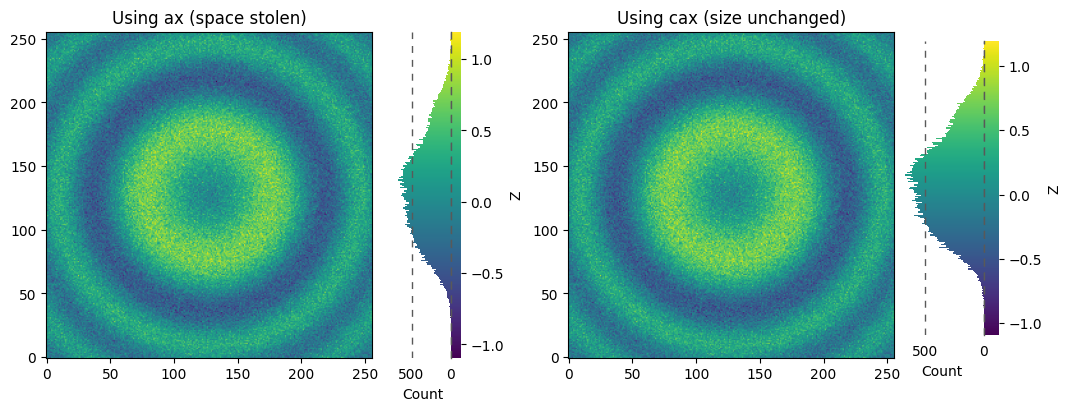

In [18]:
X, Y, Z = generate_data(256, seed=2)
fig = plt.figure(figsize=(9, 4), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

# Left: using ax (steals space)
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(Z, origin='lower')
ax1.set_title('Using ax (space stolen)')
fig.hist_colorbar(data=Z, mappable=im1, ax=ax1, location='right', label='Z', hist_label='Count')

# Right: using cax (no effect on subplot size)
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(Z, origin='lower')
ax2.set_title('Using cax (size unchanged)')
cax2 = inset_axes(ax2, width='30%', height='90%', loc='lower left',
                  bbox_to_anchor=(1.02, 0.07, 1, 1),
                  bbox_transform=ax2.transAxes, borderpad=0)
fig.hist_colorbar(data=Z, mappable=im2, cax=cax2, location='right', label='Z', hist_label='Count')
plt.show()

## 3) `location` ↔ `orientation`
- `location` in {left, right} implies a vertical colorbar.
- `location` in {top, bottom} implies a horizontal colorbar.
- You can also set `orientation` and let the other be inferred.

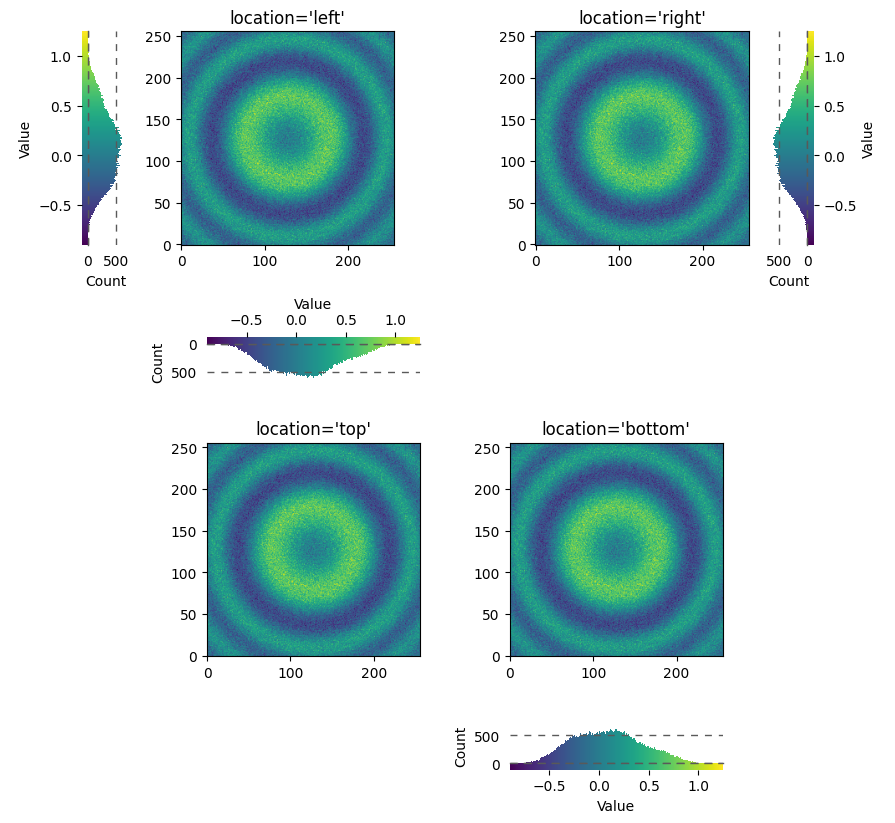

In [97]:
X, Y, Z = generate_data(256, seed=3)
fig, axs = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)
locs = [['left', 'right'], ['top', 'bottom']]
for i, row in enumerate(locs):
    for j, loc in enumerate(row):
        ax = axs[i, j]
        im = ax.imshow(Z, origin='lower')
        ax.set_title(f"location='{loc}'")
        fig.hist_colorbar(data=Z, mappable=im, ax=ax, location=loc, label='Value', hist_label='Count')

## 4) Layout: `fraction` and `hist_fraction`
- `fraction` controls how much of the parent axes HistColorbar occupies (wider bar).
- `hist_fraction` controls the split between histogram and the pure colorbar gradient inside the widget.

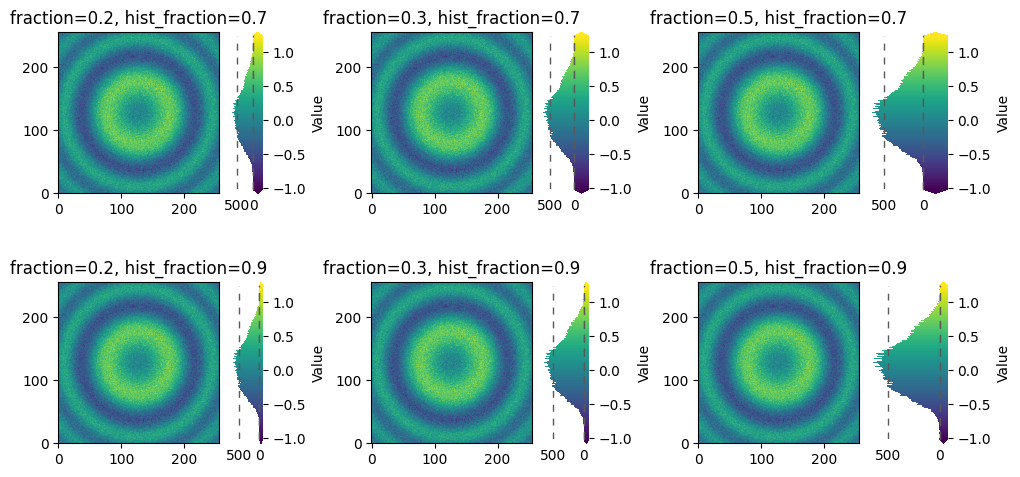

In [24]:
X, Y, Z = generate_data(256, seed=4)
fig, axs = plt.subplots(2, 3, figsize=(10, 5), constrained_layout=True)
for ax_row, frac_hist in zip(axs, [0.7, 0.9]):
    for ax, frac in zip(ax_row, [0.2, 0.3, 0.5]):
        im = ax.imshow(Z, origin='lower')
        fig.hist_colorbar(Z, im, ax=ax, location='right', extend='both',
                        fraction=frac, hist_fraction=frac_hist, label='Value')
        ax.set_title(f'fraction={frac}, hist_fraction={frac_hist}')
plt.show()

## 5) Handling Out-of-Range Values: `extend`
When your data exceed the `norm` range, set `extend` to show triangular indicators at the bar ends.
- `extend='min'` / `'max'` / `'both'` / `'neither'`
- Ensure your `norm` reflects the desired display range; `extend` is a hint, not a fix.

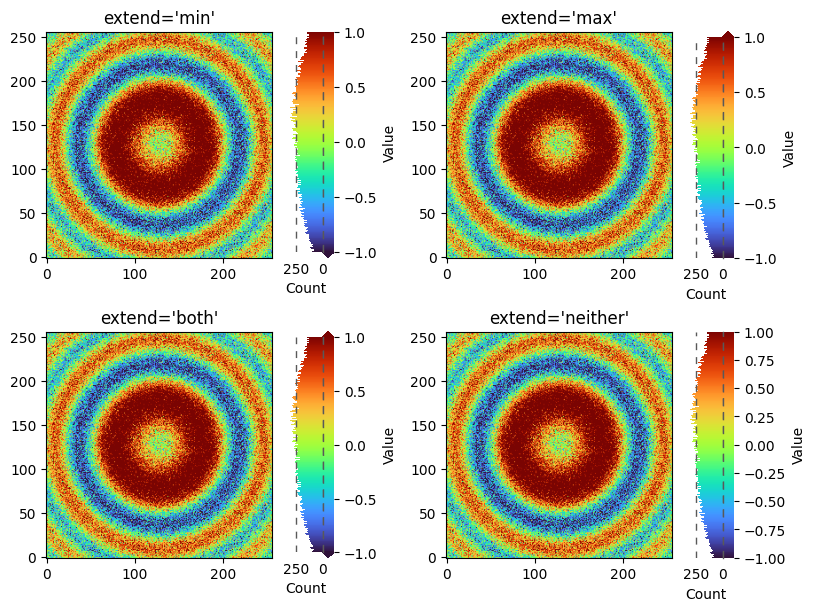

In [101]:
X, Y, Z = generate_data(256, seed=5)
Z2 = Z * 2.0  # Create out-of-range values
norm = Normalize(vmin=-1.0, vmax=1.0)
fig, axs = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
for ax, ext in zip(axs.flat, ['min', 'max', 'both', "neither"]):
    im = ax.imshow(Z2, origin='lower', norm=norm, cmap='turbo')
    ax.set_title(f"extend='{ext}'")
    fig.hist_colorbar(Z2, im, ax=ax, location='right', hist_fraction=0.75,
                      extend=ext, label='Value', hist_label='Count')

## 6) Histogram Count Scale: `log` and `min_count`
Use `log=True` for heavy-tailed distributions so small but important modes are visible.
- `min_count='auto'` uses 0.5 for log, 0 for linear.
- You can pass a specific positive value (e.g., 10) to trim the low end for clarity.

Note: `log=True` affects the histogram count axis, not the data `norm`.
This is often exactly what you want to avoid misleading color scaling.

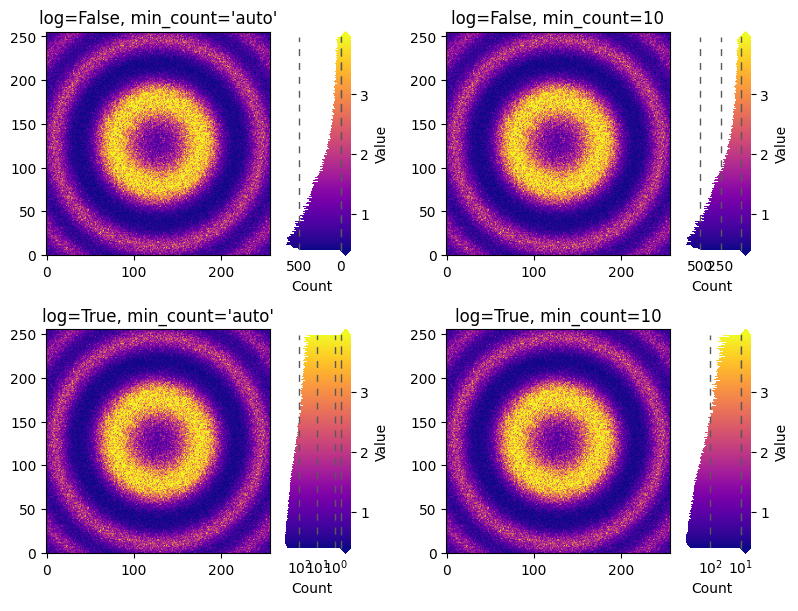

In [ ]:
X, Y, Z = generate_data(256, seed=6)
Zpos = np.exp(2 * Z)  # Positive values with heavy tail
norm = Normalize(vmin=np.percentile(Zpos, 5), vmax=np.percentile(Zpos, 95))
fig, axs = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
titles = ["log=False, min_count='auto'", "log=False, min_count=10", 
          "log=True, min_count='auto'", "log=True, min_count=10"]
for ax, log, minc, title in zip(axs.flat,[False, False, True, True],['auto', 10, 'auto', 10], titles):
    im = ax.imshow(Zpos, origin='lower', cmap='plasma', norm=norm)
    ax.set_title(title)
    fig.hist_colorbar(Zpos, im, ax=ax, extend='both', log=log, min_count=minc, 
                      fraction=0.3, label='Value', hist_label='Count')

## 7) Outline and Dividers Style
- `outline=True` shows axis frames to make the widget boundaries clear.
- `divider_style` customizes the separator line (e.g., solid vs dashed).

Use subtle colors and thin lines to keep the plot clean.

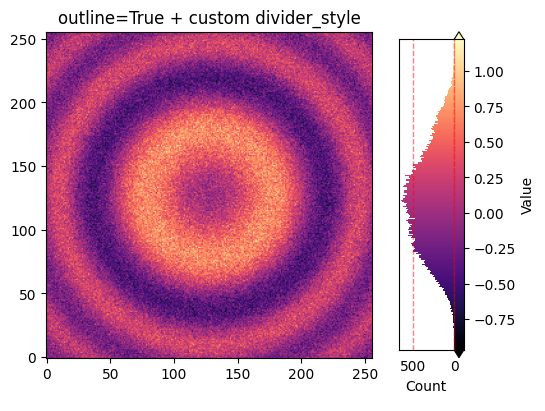

In [124]:
X, Y, Z = generate_data(256, seed=7)
fig, ax = plt.subplots(figsize=(5.8, 4), constrained_layout=True)
im = ax.imshow(Z, origin='lower', cmap='magma')
fig.hist_colorbar(
    Z, im, ax=ax, location='right', outline=True, extend='both',
    divider_style={'color': 'r', 'linestyle': '--', 'linewidth': 1 ,"alpha":0.5},
    label='Value', hist_label='Count'
)
ax.set_title('outline=True + custom divider_style')
plt.show()

## 8) Works with `imshow`, `contourf`, `pcolormesh`
HistColorbar can take any Matplotlib mappable (objects with `cmap` and `norm`).
This section shows three common plot types.

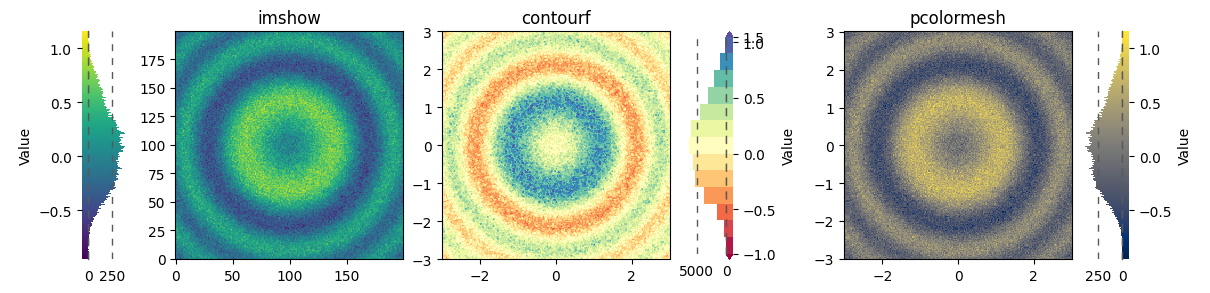

In [ ]:
X, Y, Z = generate_data(200, seed=8)
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)

# imshow
im0 = axs[0].imshow(Z, origin='lower', cmap='viridis')
axs[0].set_title('imshow')
fig.hist_colorbar(data=Z, mappable=im0, ax=axs[0], location='left', label='Value')

# contourf
cs = axs[1].contourf(X, Y, Z, levels=15, cmap='Spectral', extend='both')
axs[1].set_aspect('equal')
axs[1].set_title('contourf')
fig.hist_colorbar(data=Z, mappable=cs, ax=axs[1], label='Value')

# pcolormesh
pc = axs[2].pcolormesh(X, Y, Z, shading='auto', cmap='cividis')
axs[2].set_title('pcolormesh')
axs[2].set_aspect('equal')
fig.hist_colorbar(data=Z, mappable=pc, ax=axs[2], location='right', label='Value')
plt.show()

## 9) Complex Layout (subplot_mosaic)
Combine multiple features to build an informative and polished figure.
Choose different `location`, `extend`, `outline`, `pad`, `fraction` and `log` settings per panel if needed.

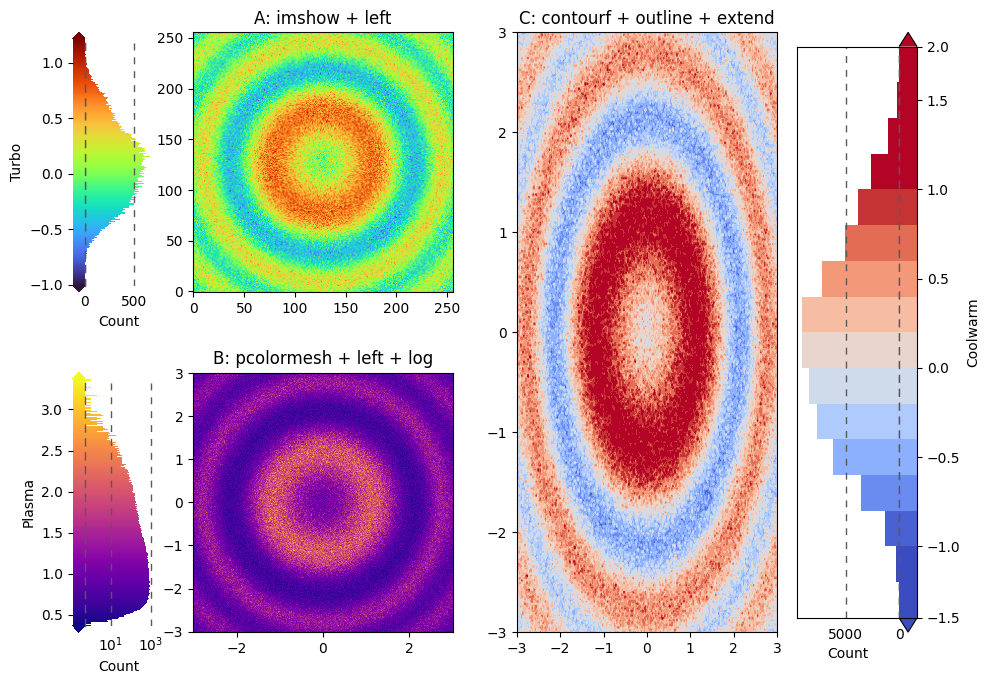

In [76]:
X, Y, Z = generate_data(256, seed=9)
fig = plt.figure(figsize=(10, 7), layout='tight')
axd = fig.subplot_mosaic([['A', 'C'],
                         ['B', 'C']])

# A: imshow + left side
imA = axd['A'].imshow(Z, origin='lower', cmap='turbo')
fig.hist_colorbar(data=Z, mappable=imA, ax=axd['A'], location='left',
                   extend='both', pad=0.1,
                   label='Turbo', hist_label='Count')

# B: pcolormesh + left side + log scale
pcB = axd['B'].pcolormesh(X, Y, np.exp(Z), shading='auto', cmap='plasma')
axd['B'].set_aspect('equal')
fig.hist_colorbar(data=np.exp(Z), mappable=pcB, ax=axd['B'], location='left',
                   log=True, extend='both', pad=0.1,
                   label='Plasma', hist_label='Count')

# C: contourf + outline + extend=both
csC = axd['C'].contourf(X, Y, Z*1.5, levels=20, cmap='coolwarm', extend='both',
                         norm=Normalize(vmin=-1.0, vmax=1.0))
fig.hist_colorbar(data=Z*1.5, mappable=csC, ax=axd['C'], 
                   fraction=0.3, outline=True,
                   label='Coolwarm', hist_label='Count')

axd['A'].set_title('A: imshow + left')
axd['B'].set_title('B: pcolormesh + left + log')
axd['C'].set_title('C: contourf + outline + extend')
plt.show()


## 10) Customizing Ticks and Labels
Use the provided methods for precise control over ticks/labels on both the colorbar and histogram axes.

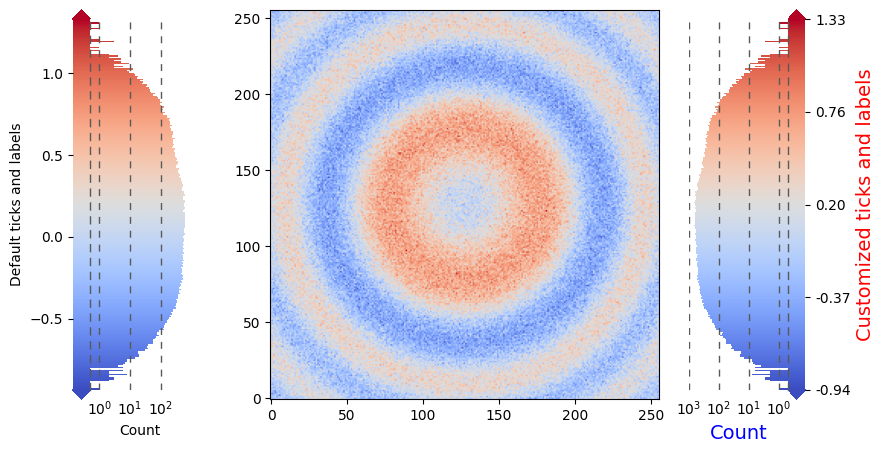

In [123]:
X, Y, Z = generate_data(256, seed=10)
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
im = ax.imshow(Z, origin='lower', cmap='coolwarm')

hcb = fig.hist_colorbar(Z, im, ax=ax, log=True, fraction=0.3, extend='both', 
            location="left", label='Default ticks and labels', hist_label='Count')

hcb1 = fig.hist_colorbar(Z, im, ax=ax, log=True, fraction=0.3, extend='both')
# Customize colorbar ticks and labels
ticks = np.linspace(Z.min(), Z.max(), 5)
hcb1.set_cbar_ticks(ticks, labels=[f'{t:.2f}' for t in ticks])
# Customize histogram ticks
hcb1.set_hist_ticks([1, 10, 100, 1000])
# set lables
hcb1.set_label('Customized ticks and labels', fontsize=14, color='red')
# set hist label
hcb1.set_hist_label('Count', fontsize=14, color='blue')
plt.show()

## Best Practices
- Keep the colobar gradient visible: decrease `hist_fraction` if pure colobar part are too narrow or increase `fraction`.
- Use `log=True` for heavy-tailed counts; keep color `norm` linear unless you intend a non-linear color mapping.
- Avoid label clutter: choose `location` to minimize collisions with axes labels/ticks.
- Prefer `ax` for simplicity; switch to `cax` when you must lock the main plot size.

## Troubleshooting
- Empty histogram? Ensure your `data` are finite (no all-NaN/inf after masking).
- Wrong orientation? `location` determines orientation if not explicitly set.
- Triangles not showing? If using `countourf`, ensure `extend` is set in coutourf function, not hist_colorbar.
- Overlapping labels? Trying set layout to 'tight' or 'constrained' or use `pad` to adjust spacing.
- Log scale error? `min_count` must be positive in log mode.

## API Cheat Sheet
Construct via the Figure method (registered by importing `faninsar.plotting`):

```python
hcb = fig.hist_colorbar(
    data, mappable=im_or_cs, ax=ax_or_axes_array,  # or use cax=...
    location='right',  # or 'left'/'top'/'bottom'
    fraction=0.2, hist_fraction=0.85, pad=None, shrink=1.0,
    extend='neither', extendfrac=0.025,
    outline=False, log=False, min_count='auto',
    label='Colorbar label', hist_label='Histogram count',
    divider_style={'color': '0.35','linestyle': (0,(5,5)),'linewidth': 1},
)

# After creation
hcb.set_cbar_ticks([...], labels=[...]); hcb.set_hist_ticks([...], labels=[...])
hcb.set_cbar_label('...'); hcb.set_hist_label('...')
hcb.cbar_tick_params(length=0); hcb.hist_tick_params(grid_alpha=0.3)
```

See the docstrings in `faninsar.plotting.colorbar` for full details.